# Ablation Study — Custom CNN ("This Work")

This notebook systematically isolates the impact of individual design choices in the CNN defined in `CNN-1.ipynb`.

**What is an ablation study?**  
We start from the trained baseline model, then *change one thing at a time*, retrain for a fixed budget of epochs, and compare validation metrics. This tells us which design choices actually matter.

**Studies covered:**
| # | Study | What we vary |
|---|-------|--------------|
| 0 | Baseline | Load trained checkpoint — no changes |
| 1 | Activation function | LeakyReLU vs ReLU vs ELU vs Tanh |
| 2 | Conv channel width | Narrower, baseline, wider |
| 3 | Pooling type | MaxPool vs AvgPool vs more aggressive MaxPool |
| 4 | Class loss weights | [1,10] vs [1,25] vs [1,50] vs [1,100] vs [1,1] |
| 5 | FC hidden size | 10 vs 32 vs 64 vs 128 |

**Rule:** Only one thing changes per variant. Everything else stays identical to the baseline.

---
## Step 1 — Imports and Reproducibility

In [3]:
import os, random, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 24
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Imports OK")

Imports OK


---
## Step 2 — Configuration

Edit the paths and the ablation epoch budget here. All ablation variants will be trained for `N_ABLATION_EPOCHS` epochs so results are comparable.

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────
PROJECT_DIR       = '/Users/soheilgolara/Downloads/Project'
TRAIN_PT          = os.path.join(PROJECT_DIR, 'balanced_train_0p2.pt')
VAL_PT            = os.path.join(PROJECT_DIR, 'balanced_val_0p2.pt')
CHECKPOINT_PATH   = os.path.join(PROJECT_DIR, 'simple_model_checkpoint.pt')

# ── Ablation training budget ──────────────────────────────────────────
# Increase for better estimates; 10 is a good starting point.
N_ABLATION_EPOCHS = 10
BATCH_SIZE        = 8
LR                = 1e-3

# ── Device ────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device : {device}')
print(f'Ablation epochs : {N_ABLATION_EPOCHS}')

Device : mps
Ablation epochs : 10


---
## Step 3 — Load Data

In [5]:
def load_from_pt(train_path, val_path, batch_size=8):
    train_data = torch.load(train_path, weights_only=False)
    val_data   = torch.load(val_path,   weights_only=False)
    train_ds   = TensorDataset(train_data['imgs'], train_data['labels'])
    val_ds     = TensorDataset(val_data['imgs'],   val_data['labels'])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

train_loader, val_loader = load_from_pt(TRAIN_PT, VAL_PT, BATCH_SIZE)

# Quick sanity check
for split, loader in [('Train', train_loader), ('Val', val_loader)]:
    labels = loader.dataset.tensors[1]
    classes, counts = torch.unique(labels, return_counts=True)
    print(f'{split}: ' + ', '.join(f'class {c.item()}={n.item()}' for c, n in zip(classes, counts)))

Train: class 0=10919, class 1=390
Val: class 0=2730, class 1=98


---
## Step 4 — Evaluation Utility

A single function that runs the model on a dataloader and returns a dict of metrics.
We reuse it for every ablation variant.

In [6]:
def evaluate(model, loader, device):
    """Returns dict with accuracy, precision, recall, f1, auc_roc."""
    model.eval()
    all_pred, all_true, all_prob = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            probs  = F.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_pred.append(preds.cpu().numpy())
            all_true.append(labels.cpu().numpy())
            all_prob.append(probs[:, 1].cpu().numpy())

    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)
    y_prob = np.concatenate(all_prob)

    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'auc_roc'  : roc_auc_score(y_true, y_prob),
    }

def print_metrics(name, metrics):
    print(f"\n{'─'*40}")
    print(f" {name}")
    print(f"{'─'*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

print("evaluate() ready")

evaluate() ready


---
## Step 5 — Training Utility

A compact training loop used for every ablation variant. It takes a freshly constructed model, trains it for `n_epochs`, and returns the trained model plus a history dict.

In [7]:
def train_ablation(model, train_loader, val_loader, n_epochs,
                   criterion, lr, device, label='model'):
    """
    Trains `model` for `n_epochs` and returns:
        - trained model
        - history dict  {'train_loss': [...], 'val_f1': [...]}
        - final metrics dict from evaluate()
    """
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

    model = model.to(device)
    optimizer = torch.optim.SGD(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    history = {'train_loss': [], 'val_f1': []}

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        for imgs, labels in tqdm(train_loader, desc=f'[{label}] epoch {epoch}', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        avg_loss = np.mean(epoch_losses)
        metrics  = evaluate(model, val_loader, device)
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(metrics['f1'])
        print(f'[{label}] epoch {epoch:>2}  loss={avg_loss:.4f}  val_f1={metrics["f1"]:.4f}')

    final_metrics = evaluate(model, val_loader, device)
    return model, history, final_metrics

print("train_ablation() ready")

train_ablation() ready


---
## Step 6 — Baseline: Load Trained Checkpoint

This is the exact architecture from `CNN-1.ipynb` loaded with its fully-trained weights (20 epochs).
All ablation variants will be compared against these numbers.

In [8]:
# ── Baseline architecture (exact copy from CNN-1) ─────────────────────
class SimpleCNN_Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3)
        self.conv2 = nn.Conv2d(8, 6, 2)
        self.conv3 = nn.Conv2d(6, 3, 3)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(88935, 10)
        self.fc2   = nn.Linear(10, 2)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = F.leaky_relu(self.conv2(x))
        x = F.leaky_relu(self.conv3(x))
        x = self.pool3(x)
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        return self.fc2(x)

# ── Load checkpoint ───────────────────────────────────────────────────
baseline_model = SimpleCNN_Baseline()
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
baseline_model.load_state_dict(checkpoint['model_state_dict'])
baseline_model = baseline_model.to(device)
print(f"Checkpoint loaded (trained for {checkpoint.get('epoch', '?')+1} epochs)")

# ── Evaluate ──────────────────────────────────────────────────────────
baseline_metrics = evaluate(baseline_model, val_loader, device)
print_metrics('Baseline (trained checkpoint)', baseline_metrics)

# Store results table — we'll append every ablation variant to this
results_table = [{'variant': 'Baseline (checkpoint)', **baseline_metrics}]

Checkpoint loaded (trained for 20 epochs)

────────────────────────────────────────
 Baseline (trained checkpoint)
────────────────────────────────────────
  accuracy    : 0.9996
  precision   : 1.0000
  recall      : 0.9898
  f1          : 0.9949
  auc_roc     : 1.0000


---
## Ablation 1 — Activation Function

**Question**: Does LeakyReLU help compared to standard ReLU, ELU, or Tanh?

**What changes**: only the activation in the 3 conv layers and FC1.  
**What stays the same**: channel widths `[8, 6, 3]`, pool type, FC size, loss weights, LR.

Each variant is trained from random initialisation for `N_ABLATION_EPOCHS` epochs.

In [9]:
class SimpleCNN_Activation(nn.Module):
    """Same as baseline but activation is a parameter."""
    def __init__(self, activation_fn):
        super().__init__()
        self.act   = activation_fn
        self.conv1 = nn.Conv2d(3, 8, 3)
        self.conv2 = nn.Conv2d(8, 6, 2)
        self.conv3 = nn.Conv2d(6, 3, 3)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(88935, 10)
        self.fc2   = nn.Linear(10, 2)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = self.pool3(x)
        x = torch.flatten(x, 1)
        x = self.act(self.fc1(x))
        return self.fc2(x)

# Activation variants to test
activation_variants = {
    'LeakyReLU (baseline)': F.leaky_relu,
    'ReLU'                : F.relu,
    'ELU'                 : F.elu,
    'Tanh'                : torch.tanh,
}

# Shared loss for this ablation
weights_baseline = torch.tensor([1.0, 50.0]).to(device)
criterion_baseline = nn.CrossEntropyLoss(weight=weights_baseline)

ablation1_histories = {}
ablation1_metrics   = {}

for name, act_fn in activation_variants.items():
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    model_v = SimpleCNN_Activation(act_fn)
    _, history, metrics = train_ablation(
        model_v, train_loader, val_loader,
        n_epochs=N_ABLATION_EPOCHS,
        criterion=criterion_baseline, lr=LR,
        device=device, label=name
    )
    ablation1_histories[name] = history
    ablation1_metrics[name]   = metrics
    print_metrics(name, metrics)
    results_table.append({'variant': f'Ablation1: {name}', **metrics})


Training: LeakyReLU (baseline)


[LeakyReLU (baseline)] epoch  0  loss=0.5450  val_f1=0.0000


[LeakyReLU (baseline)] epoch  1  loss=0.4073  val_f1=0.8737


[LeakyReLU (baseline)] epoch  2  loss=0.0431  val_f1=0.8750


[LeakyReLU (baseline)] epoch  3  loss=0.0071  val_f1=0.9897


...

[Tanh] epoch  5  loss=0.0086  val_f1=1.0000


[Tanh] epoch  6  loss=0.0072  val_f1=1.0000


[Tanh] epoch  7  loss=0.0061  val_f1=1.0000


[Tanh] epoch  8  loss=0.0052  val_f1=1.0000


[Tanh] epoch  9  loss=0.0046  val_f1=1.0000

────────────────────────────────────────
 Tanh
────────────────────────────────────────
  accuracy    : 1.0000
  precision   : 1.0000
  recall      : 1.0000
  f1          : 1.0000
  auc_roc     : 1.0000


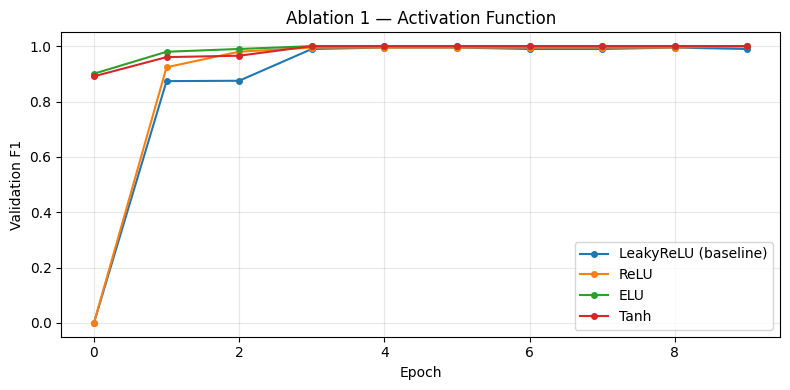

In [10]:
# ── Plot: F1 vs epoch for each activation ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for name, hist in ablation1_histories.items():
    ax.plot(hist['val_f1'], marker='o', ms=4, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation F1')
ax.set_title('Ablation 1 — Activation Function')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Ablation 2 — Conv Channel Width

**Question**: Does the number of filters in the conv layers matter?

**What changes**: the number of output channels in each conv layer.  
**What stays the same**: activation (LeakyReLU), pool, FC size, loss weights, LR.

Because the channel count changes, the flattened size fed to FC1 changes too. We compute it automatically with a dummy forward pass.

In [12]:
class SimpleCNN_Width(nn.Module):
    """Parameterised by [c1, c2, c3] channel widths."""
    def __init__(self, channels, fc_hidden=10, img_shape=(3, 248, 496)):
        super().__init__()
        c1, c2, c3 = channels
        self.conv1 = nn.Conv2d(3,  c1, 3)
        self.conv2 = nn.Conv2d(c1, c2, 2)
        self.conv3 = nn.Conv2d(c2, c3, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        # compute flattened size automatically
        flat = self._get_flat_size(img_shape)
        self.fc1 = nn.Linear(flat, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, 2)

    def _get_flat_size(self, img_shape):
        with torch.no_grad():
            dummy = torch.zeros(1, *img_shape)
            x = F.leaky_relu(self.conv1(dummy))
            x = F.leaky_relu(self.conv2(x))
            x = F.leaky_relu(self.conv3(x))
            x = self.pool(x)
            return x.numel()

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = F.leaky_relu(self.conv2(x))
        x = F.leaky_relu(self.conv3(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        return self.fc2(x)

# Width variants:  [conv1_ch, conv2_ch, conv3_ch]
width_variants = {
    'Narrower  [3, 2, 2]'          : [3,  2,  2],
    'Narrow  [4, 3, 2]'          : [4,  3,  2],
    'Baseline [8, 6, 3]'         : [8,  6,  3],
#    'Wide   [16, 12, 6]'         : [16, 12, 6],
#    'Wider  [32, 16, 8]'         : [32, 16, 8],
}

ablation2_histories = {}
ablation2_metrics   = {}

for name, channels in width_variants.items():
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    model_v = SimpleCNN_Width(channels)
    flat_size = model_v.fc1.in_features
    total_params = sum(p.numel() for p in model_v.parameters())
    print(f'  flat size={flat_size:,}   total params={total_params:,}')
    _, history, metrics = train_ablation(
        model_v, train_loader, val_loader,
        n_epochs=N_ABLATION_EPOCHS,
        criterion=criterion_baseline, lr=LR,
        device=device, label=name
    )
    ablation2_histories[name] = history
    ablation2_metrics[name]   = metrics
    print_metrics(name, metrics)
    results_table.append({'variant': f'Ablation2: {name}', **metrics})


Training: Narrower  [3, 2, 2]
  flat size=59,290   total params=593,080


[Narrower  [3, 2, 2]] epoch  0  loss=0.3481  val_f1=0.8205


[Narrower  [3, 2, 2]] epoch  1  loss=0.0286  val_f1=0.9652


[Narrower  [3, 2, 2]] epoch  2  loss=0.0066  val_f1=0.9949


[Narrower  [3, 2, 2]] epoch  3  loss=0.0019  val_f1=0.9949


...

[Baseline [8, 6, 3]] epoch  5  loss=0.0007  val_f1=0.9949


[Baseline [8, 6, 3]] epoch  6  loss=0.0006  val_f1=0.9949


[Baseline [8, 6, 3]] epoch  7  loss=0.0004  val_f1=0.9949


[Baseline [8, 6, 3]] epoch  8  loss=0.0003  val_f1=0.9949


[Baseline [8, 6, 3]] epoch  9  loss=0.0003  val_f1=0.9949

────────────────────────────────────────
 Baseline [8, 6, 3]
────────────────────────────────────────
  accuracy    : 0.9996
  precision   : 0.9899
  recall      : 1.0000
  f1          : 0.9949
  auc_roc     : 1.0000


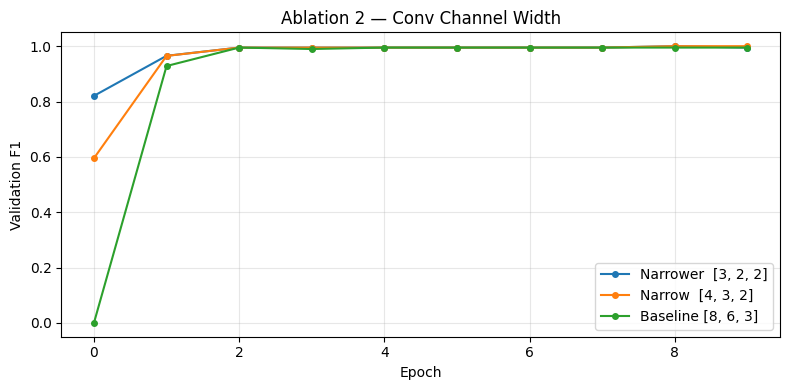

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, hist in ablation2_histories.items():
    ax.plot(hist['val_f1'], marker='o', ms=4, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation F1')
ax.set_title('Ablation 2 — Conv Channel Width')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Ablation 3 — Pooling Strategy

**Question**: Does MaxPool matter, or would AvgPool / more aggressive downsampling work just as well?

**What changes**: the pooling layer type and/or stride.  
**What stays the same**: channels `[8, 6, 3]`, activation (LeakyReLU), FC size, loss weights, LR.

In [ ]:
class SimpleCNN_Pool(nn.Module):
    """Parameterised by a pooling layer."""
    def __init__(self, pool_layer, img_shape=(3, 248, 496)):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3)
        self.conv2 = nn.Conv2d(8, 6, 2)
        self.conv3 = nn.Conv2d(6, 3, 3)
        self.pool  = pool_layer
        flat = self._get_flat_size(img_shape)
        self.fc1 = nn.Linear(flat, 10)
        self.fc2 = nn.Linear(10, 2)

    def _get_flat_size(self, img_shape):
        with torch.no_grad():
            dummy = torch.zeros(1, *img_shape)
            x = F.leaky_relu(self.conv1(dummy))
            x = F.leaky_relu(self.conv2(x))
            x = F.leaky_relu(self.conv3(x))
            x = self.pool(x)
            return x.numel()

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = F.leaky_relu(self.conv2(x))
        x = F.leaky_relu(self.conv3(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        return self.fc2(x)

pool_variants = {
    'MaxPool 2×2 (baseline)'       : nn.MaxPool2d(2, 2),
    'AvgPool 2×2'                  : nn.AvgPool2d(2, 2),
    'MaxPool 4×4 (more aggressive)': nn.MaxPool2d(4, 4),
#    'AdaptiveAvgPool 64×128'       : nn.AdaptiveAvgPool2d((64, 128)),
}

ablation3_histories = {}
ablation3_metrics   = {}

for name, pool_layer in pool_variants.items():
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    model_v = SimpleCNN_Pool(pool_layer)
    flat_size = model_v.fc1.in_features
    print(f'  flat size after pool = {flat_size:,}')
    _, history, metrics = train_ablation(
        model_v, train_loader, val_loader,
        n_epochs=N_ABLATION_EPOCHS,
        criterion=criterion_baseline, lr=LR,
        device=device, label=name
    )
    ablation3_histories[name] = history
    ablation3_metrics[name]   = metrics
    print_metrics(name, metrics)
    results_table.append({'variant': f'Ablation3: {name}', **metrics})


Training: MaxPool 2×2 (baseline)
  flat size after pool = 88,935


[MaxPool 2×2 (baseline)] epoch  0  loss=0.4743  val_f1=0.0000


[MaxPool 2×2 (baseline)] epoch  1  loss=0.0720  val_f1=0.9282


[MaxPool 2×2 (baseline)] epoch  2  loss=0.0081  val_f1=0.9949


[MaxPool 2×2 (baseline)] epoch  3  loss=0.0021  val_f1=0.9898


...

[MaxPool 4×4 (more aggressive)] epoch  6  loss=0.0013  val_f1=0.9898


[MaxPool 4×4 (more aggressive)] epoch  7  loss=0.0009  val_f1=0.9898


[MaxPool 4×4 (more aggressive)] epoch  8  loss=0.0006  val_f1=0.9949


[MaxPool 4×4 (more aggressive)] epoch  9  loss=0.0005  val_f1=0.9949

────────────────────────────────────────
 MaxPool 4×4 (more aggressive)
────────────────────────────────────────
  accuracy    : 0.9996
  precision   : 1.0000
  recall      : 0.9898
  f1          : 0.9949
  auc_roc     : 1.0000

Training: AdaptiveAvgPool 64×128
  flat size after pool = 24,576


RuntimeError: Adaptive pool MPS: input sizes must be divisible by output sizes. Non-divisible input sizes are not implemented on MPS device yet. For now, you can manually transfer tensor to cpu in this case. Please refer to [this issue](https://github.com/pytorch/pytorch/issues/96056)

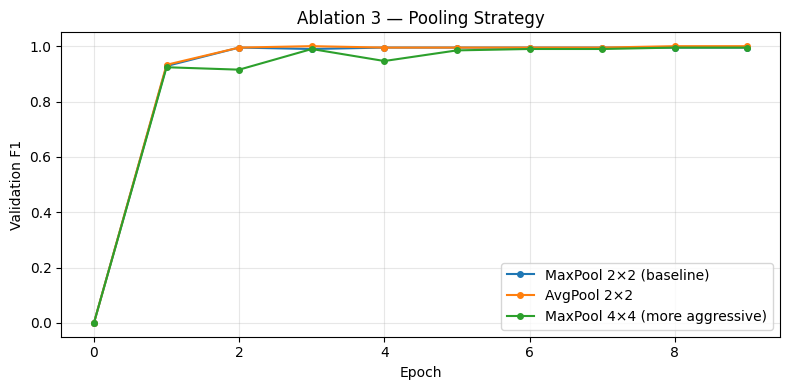

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, hist in ablation3_histories.items():
    ax.plot(hist['val_f1'], marker='o', ms=4, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation F1')
ax.set_title('Ablation 3 — Pooling Strategy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Ablation 4 — Class Loss Weights

**Question**: How sensitive is the model to the minority-class penalty weight?

**What changes**: the `[w_neg, w_pos]` weights in `CrossEntropyLoss`.  
**What stays the same**: architecture (baseline channels, baseline activation), LR.

> **Tip**: Because the architecture is unchanged, we *could* fine-tune from the checkpoint here. 
> For a fair comparison, we train each variant from scratch instead.

In [16]:
weight_variants = {
    'No weighting  [1, 1]'  : [1.0,   1.0],
    'Light        [1, 10]'  : [1.0,  10.0],
    'Medium       [1, 25]'  : [1.0,  25.0],
    'Baseline     [1, 50]'  : [1.0,  50.0],
    'Heavy       [1, 100]'  : [1.0, 100.0],
}

ablation4_histories = {}
ablation4_metrics   = {}

for name, w in weight_variants.items():
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    criterion_v = nn.CrossEntropyLoss(weight=torch.tensor(w).to(device))
    model_v = SimpleCNN_Baseline()   # fresh weights each time
    _, history, metrics = train_ablation(
        model_v, train_loader, val_loader,
        n_epochs=N_ABLATION_EPOCHS,
        criterion=criterion_v, lr=LR,
        device=device, label=name
    )
    ablation4_histories[name] = history
    ablation4_metrics[name]   = metrics
    print_metrics(name, metrics)
    results_table.append({'variant': f'Ablation4: {name}', **metrics})


Training: No weighting  [1, 1]


[No weighting  [1, 1]] epoch  0  loss=0.4274  val_f1=0.0000


[No weighting  [1, 1]] epoch  1  loss=0.1425  val_f1=0.0000


[No weighting  [1, 1]] epoch  2  loss=0.1057  val_f1=0.5755


[No weighting  [1, 1]] epoch  3  loss=0.0415  val_f1=0.9082


...

[Heavy       [1, 100]] epoch  5  loss=0.0007  val_f1=0.9949


[Heavy       [1, 100]] epoch  6  loss=0.0006  val_f1=0.9949


[Heavy       [1, 100]] epoch  7  loss=0.0004  val_f1=0.9949


[Heavy       [1, 100]] epoch  8  loss=0.0003  val_f1=0.9949


[Heavy       [1, 100]] epoch  9  loss=0.0003  val_f1=0.9949

────────────────────────────────────────
 Heavy       [1, 100]
────────────────────────────────────────
  accuracy    : 0.9996
  precision   : 0.9899
  recall      : 1.0000
  f1          : 0.9949
  auc_roc     : 1.0000


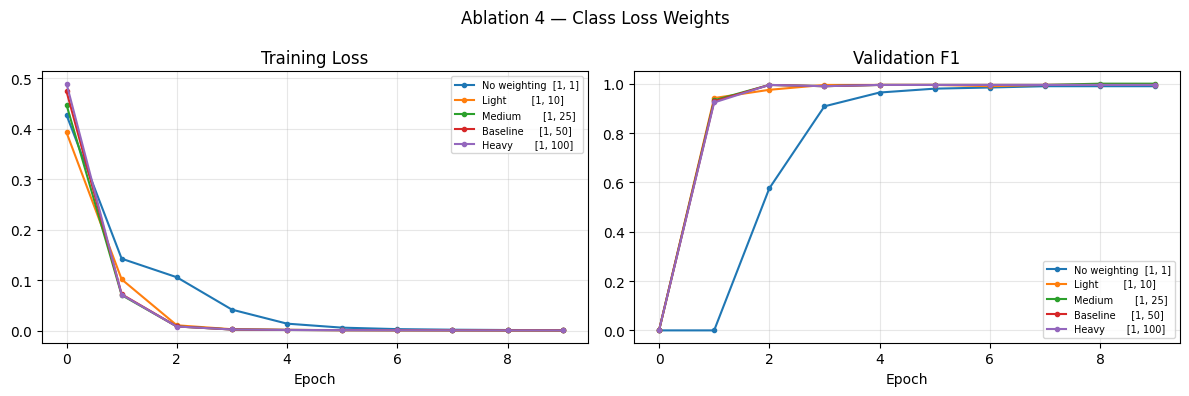

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in ablation4_histories.items():
    axes[0].plot(hist['train_loss'], marker='o', ms=3, label=name)
    axes[1].plot(hist['val_f1'],     marker='o', ms=3, label=name)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

plt.suptitle('Ablation 4 — Class Loss Weights')
plt.tight_layout(); plt.show()

---
## Ablation 5 — FC Hidden Dimension

**Question**: Is the bottleneck FC hidden size of 10 enough, or does a larger hidden layer help?

**What changes**: the number of units in FC1 (`fc1` output, `fc2` input).  
**What stays the same**: conv channels, activation, pooling, loss weights, LR.

In [18]:
class SimpleCNN_FCSize(nn.Module):
    """Parameterised by the FC hidden size."""
    def __init__(self, fc_hidden):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3)
        self.conv2 = nn.Conv2d(8, 6, 2)
        self.conv3 = nn.Conv2d(6, 3, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(88935, fc_hidden)
        self.fc2   = nn.Linear(fc_hidden, 2)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x))
        x = F.leaky_relu(self.conv2(x))
        x = F.leaky_relu(self.conv3(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.leaky_relu(self.fc1(x))
        return self.fc2(x)

fc_variants = {
    'FC hidden = 10 (baseline)': 10,
    'FC hidden = 32'           : 32,
    'FC hidden = 64'           : 64,
    'FC hidden = 128'          : 128,
}

ablation5_histories = {}
ablation5_metrics   = {}

for name, fc_hidden in fc_variants.items():
    print(f"\n{'='*50}\nTraining: {name}\n{'='*50}")
    model_v = SimpleCNN_FCSize(fc_hidden)
    total_params = sum(p.numel() for p in model_v.parameters())
    print(f'  total params = {total_params:,}')
    _, history, metrics = train_ablation(
        model_v, train_loader, val_loader,
        n_epochs=N_ABLATION_EPOCHS,
        criterion=criterion_baseline, lr=LR,
        device=device, label=name
    )
    ablation5_histories[name] = history
    ablation5_metrics[name]   = metrics
    print_metrics(name, metrics)
    results_table.append({'variant': f'Ablation5: {name}', **metrics})


Training: FC hidden = 10 (baseline)
  total params = 889,969


[FC hidden = 10 (baseline)] epoch  0  loss=0.4743  val_f1=0.0000


[FC hidden = 10 (baseline)] epoch  1  loss=0.0720  val_f1=0.9282


[FC hidden = 10 (baseline)] epoch  2  loss=0.0081  val_f1=0.9949


[FC hidden = 10 (baseline)] epoch  3  loss=0.0021  val_f1=0.9898


...

[FC hidden = 128] epoch  5  loss=0.0007  val_f1=0.9949


[FC hidden = 128] epoch  6  loss=0.0006  val_f1=0.9949


[FC hidden = 128] epoch  7  loss=0.0004  val_f1=0.9949


[FC hidden = 128] epoch  8  loss=0.0003  val_f1=1.0000


[FC hidden = 128] epoch  9  loss=0.0003  val_f1=1.0000

────────────────────────────────────────
 FC hidden = 128
────────────────────────────────────────
  accuracy    : 1.0000
  precision   : 1.0000
  recall      : 1.0000
  f1          : 1.0000
  auc_roc     : 1.0000


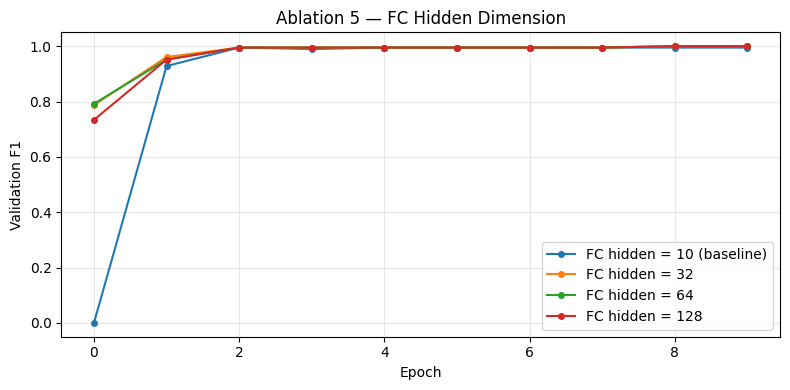

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, hist in ablation5_histories.items():
    ax.plot(hist['val_f1'], marker='o', ms=4, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation F1')
ax.set_title('Ablation 5 — FC Hidden Dimension')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Summary — All Ablation Results

This table collects every variant. Look for the row with the highest F1 or AUC-ROC to identify the best configuration.

In [20]:
df = pd.DataFrame(results_table).set_index('variant')
df = df.round(4)

# Highlight the best value in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

display(df.style.apply(highlight_max, axis=0))

,accuracy,precision,recall,f1,auc_roc
variant,,,,,
Baseline (checkpoint),0.999600,1.000000,0.989800,0.994900,1.000000
Ablation1: LeakyReLU (baseline),0.999300,0.989800,0.989800,0.989800,1.000000
Ablation1: ReLU,1.000000,1.000000,1.000000,1.000000,1.000000
Ablation1: ELU,1.000000,1.000000,1.000000,1.000000,1.000000
Ablation1: Tanh,1.000000,1.000000,1.000000,1.000000,1.000000
"Ablation2: Narrower [3, 2, 2]",0.999600,0.989900,1.000000,0.994900,1.000000
"Ablation2: Narrow [4, 3, 2]",1.000000,1.000000,1.000000,1.000000,1.000000
"Ablation2: Baseline [8, 6, 3]",0.999600,0.989900,1.000000,0.994900,1.000000
Ablation3: MaxPool 2×2 (baseline),0.999600,0.989900,1.000000,0.994900,1.000000


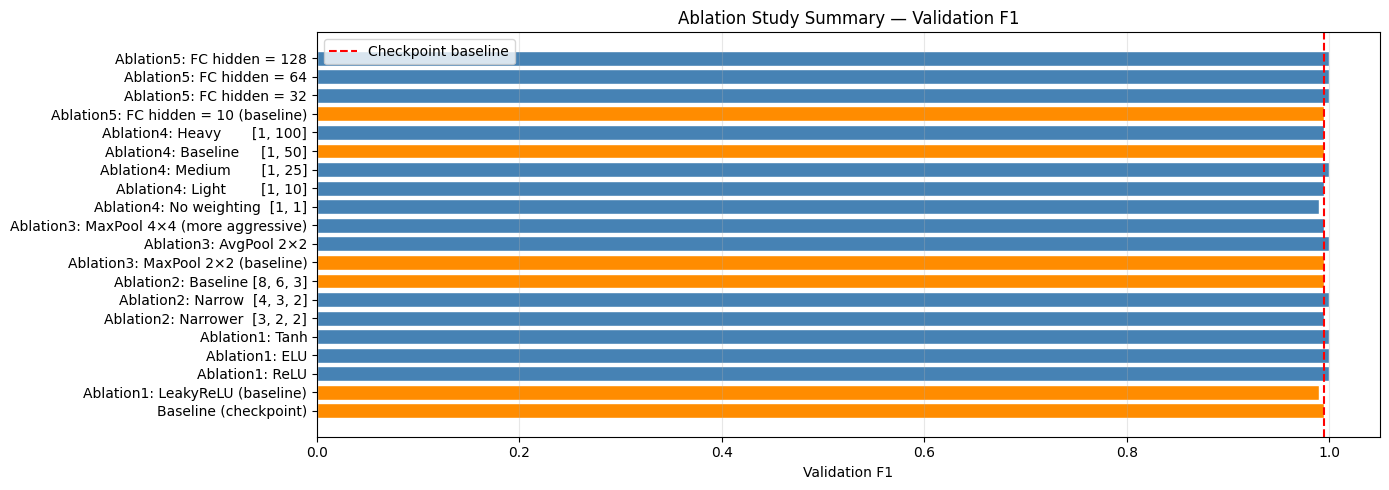

In [21]:
# ── Bar chart: F1 across all variants ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if 'baseline' not in v.lower() else 'darkorange'
          for v in df.index]
ax.barh(df.index, df['f1'], color=colors, edgecolor='white')
ax.axvline(df.loc['Baseline (checkpoint)', 'f1'], color='red', lw=1.5,
           linestyle='--', label='Checkpoint baseline')
ax.set_xlabel('Validation F1')
ax.set_title('Ablation Study Summary — Validation F1')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
# ── Save summary to CSV ───────────────────────────────────────────────
out_path = os.path.join(PROJECT_DIR, 'ablation_results.csv')
df.to_csv(out_path)
print(f'Results saved to {out_path}')

Results saved to /Users/soheilgolara/Downloads/Project/ablation_results.csv
